In [29]:
# Data manipulation
import pandas as pd
import numpy as np
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Preprocessing
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate,RandomizedSearchCV
from imblearn.over_sampling import SMOTE


# XGBoost
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            roc_auc_score, roc_curve, confusion_matrix, 
                            classification_report, precision_recall_curve)
from scipy.stats import randint, uniform
# For comparison with other models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

we have already did the EDA

Let's split the dataset into training and testing sets. Before fitting the model, we should scale the training and testing sets. There are 2 options, one we should use the StandardScaler that follows a gaussian distribution. Then another one is the RobustScaler, I prefer use the RobustScaler because we have a heavy imbalanced dataset, the outliers could effect the outcome, it's more sensible, the standard scaler may hide the true patterns.

In [23]:
df = pd.read_csv('creditcard.csv')

# 1. Split FIRST (before any transformation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Critical!
)

# 2. Scale features (fit on training only)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Apply SMOTE (only on training data)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(y_train_balanced.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [32]:
# Define parameter grid
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 7),
    'gamma': uniform(0, 0.5)
}


# For imbalanced data, use scale_pos_weight
model = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # Handle imbalance
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter combinations to try, probably we should try 20.LOL 
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_balanced, y_train_balanced)

print("Best parameters:", random_search.best_params_)
print("Best F1 score:", random_search.best_score_)

# Best model
best_model = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'colsample_bytree': 0.7502331810559776, 'gamma': 0.0469909699204345, 'learning_rate': 0.1834840422988522, 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 252, 'subsample': 0.6620166466910976}
Best F1 score: 0.9995385779671484



TEST SET PERFORMANCE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.59      0.87      0.70        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9681
F1 Score: 0.7025


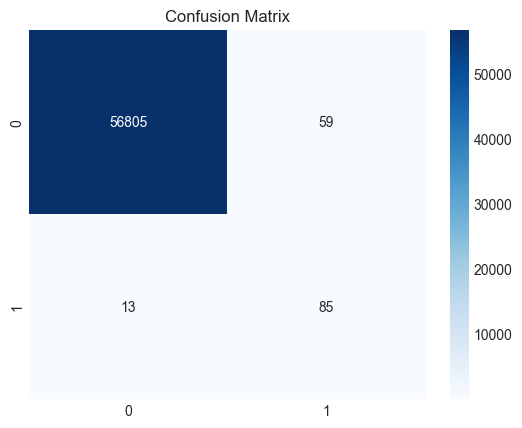

In [33]:
# 6. Evaluate on Test Set
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*50)
print("TEST SET PERFORMANCE")
print("="*50)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Currently my model is prioritizing catching fraud (high recall 87%) at the cost of more false alarms (lower precision 59%). For fraud detection, this is often acceptable, but let's check the actual numbers:

In [ ]:
print(cm)

# 59 false positives (non-fraud flagged as fraud)
# 13 false negatives (missed frauds)

[[56805    59]
 [   13    85]]


# Recall
The harmonic mean of Precision and Recall, ranging from 0 (worst) to 1 (best).--> F1-score
F1 = 2 × (Precision × Recall) / (Precision + Recall)
# Where:
Precision = TP / (TP + FP)  # Of predicted positives, how many were right?
Recall    = TP / (TP + FN)  # Of actual positives, how many did we catch?
In contrast, ROC-AUC (Receiver Operating Characteristic - Area Under Curve) measures the model's ability to discriminate between classes across all possible thresholds.

ROC curve plots:
X-axis: False Positive Rate (FPR) = FP / (FP + TN)
Y-axis: True Positive Rate (TPR) = TP / (TP + FN) = Recall

 AUC = Area under this curve (0.5 to 1.0)
0.5 = random guessing
1.0 = perfect classifier

| Metric | Optimizes | Use When |
| -------- | -------- | -------- |
| Precision	| Minimize false positives	| False alarms are expensive/harmful |
| Recall	| Minimize false negatives	| Missing positives is dangerous |
| F1	| Balance both	| Equal costs or need single metric |

In [36]:
print("XGBOOST ROC: ", roc_auc_score(y_test,y_pred))

print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

XGBOOST ROC:  0.9331546877332813
Recall: 0.8673469387755102
Precision: 0.5902777777777778


|ROC-AUC: |  0.933  |(Good - model ranks well)|
| -------- | -------- | -------- |
|Recall: |   0.867 | (Good - catches 87% of fraud)|
|Precision:| 0.590 | (Room for improvement - 41% false alarms)|

To improve the precision, we can tune the hyperparameters or weight

In [37]:
# Lower weight = less penalty for missing fraud = higher precision
weight_options = [5, 10, 15, 20, 30]  # Default was likely ~588

results = {}
for weight in weight_options:
    model = XGBClassifier(
        scale_pos_weight=weight,
        eval_metric='logloss',
        random_state=42,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1
    )
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)
    
    results[weight] = {
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    print(f"Weight {weight:3d}: P={results[weight]['precision']:.3f}, "
          f"R={results[weight]['recall']:.3f}, F1={results[weight]['f1']:.3f}")


Weight   5: P=0.293, R=0.898, F1=0.442
Weight  10: P=0.270, R=0.888, F1=0.414
Weight  15: P=0.236, R=0.888, F1=0.373
Weight  20: P=0.216, R=0.878, F1=0.347
Weight  30: P=0.202, R=0.888, F1=0.330


When scale_pos_weight is too low:

Model doesn't penalize missing fraud enough

Model becomes too confident in predicting "non-fraud"

Only predicts "fraud" for the most obvious cases

Results in low precision (few predictions, but many are wrong)

In [38]:
fraud_ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Correct ratio: {fraud_ratio:.1f}")

Correct ratio: 577.3


There are a lot of methods to improve the precision. Need more time and more proficient computer